In [9]:
# Data Imports
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ML Imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [4]:
# Visual Configurations
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

print("Setup complete.")

Setup complete.


In [5]:
# Load Data
file_path = "../data/heart.csv"
df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

Dataset Shape: 1025 rows, 14 columns

--- First 5 Rows ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
# Data Cleaning and Anomlay Detection

# Identifying and removing duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {num_duplicates}")

# If statement to process what happens if there are duplicate rows
if num_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Dropped Duplicate Rows") #confirms the process

# Check for missing values as stated null
print("\t--- Missing Value Count per Feature ---")
print(df.isnull().sum())

# Trying to see extreme cholesterol and bp outliers
#chol_outliers
cholestrol_outliers = np.where(df['chol'] > 500)[0]
bp_outliers = np.where(df['trestbps'] > 200)[0]

# How many people have this extreme cholestrol/bp rate. Accessing that list of rows with the outliers!
print(f"\nPatients with extreme Cholesterol (>500 mg/dl): {len(cholestrol_outliers)}")
print(f"Patients with extreme Resting BP (>200 mm Hg): {len(bp_outliers)}")

# Overview of summary statistics 
df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']].describe().T[['min', 'mean', 'max', 'std']]

Duplicate rows found: 723
Dropped Duplicate Rows
	--- Missing Value Count per Feature ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Patients with extreme Cholesterol (>500 mg/dl): 1
Patients with extreme Resting BP (>200 mm Hg): 0


,min,mean,max,std
age,29.0,54.420530,77.0,9.047970
trestbps,94.0,131.602649,200.0,17.563394
chol,126.0,246.500000,564.0,51.753489
thalach,71.0,149.569536,202.0,22.903527
oldpeak,0.0,1.043046,6.2,1.161452


C:\Users\haris\AppData\Local\Temp\ipykernel_23944\2338493701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
C:\Users\haris\AppData\Local\Temp\ipykernel_23944\2338493701.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Disease', 'Disease'])


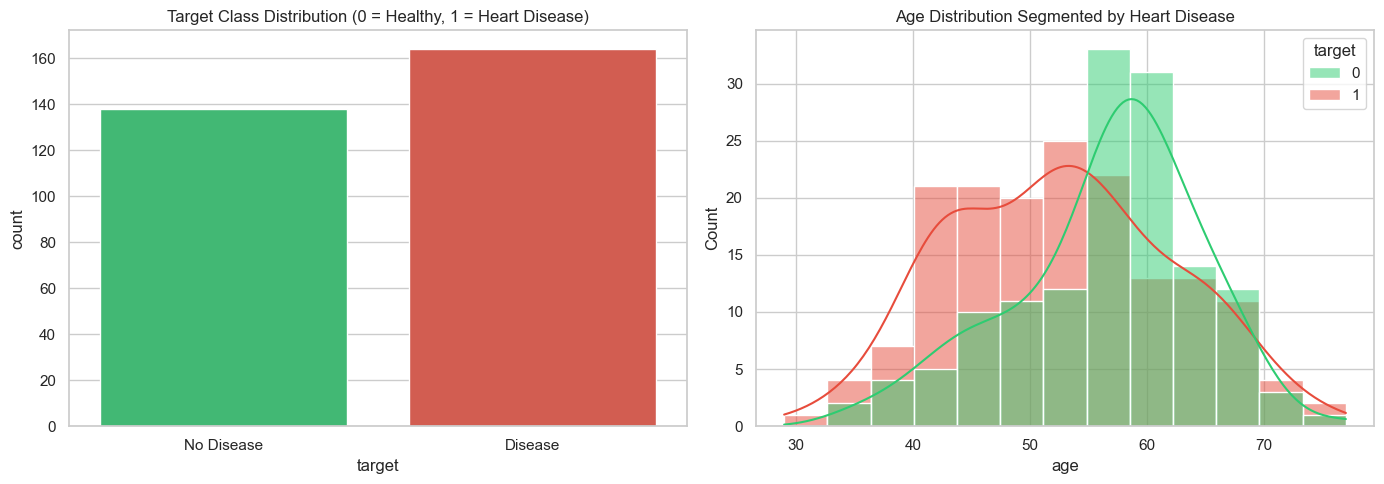

In [11]:
#EDA = Distribution and Target Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target Class Balance Plot
sns.countplot(data=df, x='target', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Target Class Distribution (0 = Healthy, 1 = Heart Disease)')
axes[0].set_xticklabels(['No Disease', 'Disease'])

# Age Distribution by Target
sns.histplot(data=df, x='age', hue='target', kde=True, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Age Distribution Segmented by Heart Disease')

plt.tight_layout()
plt.show()

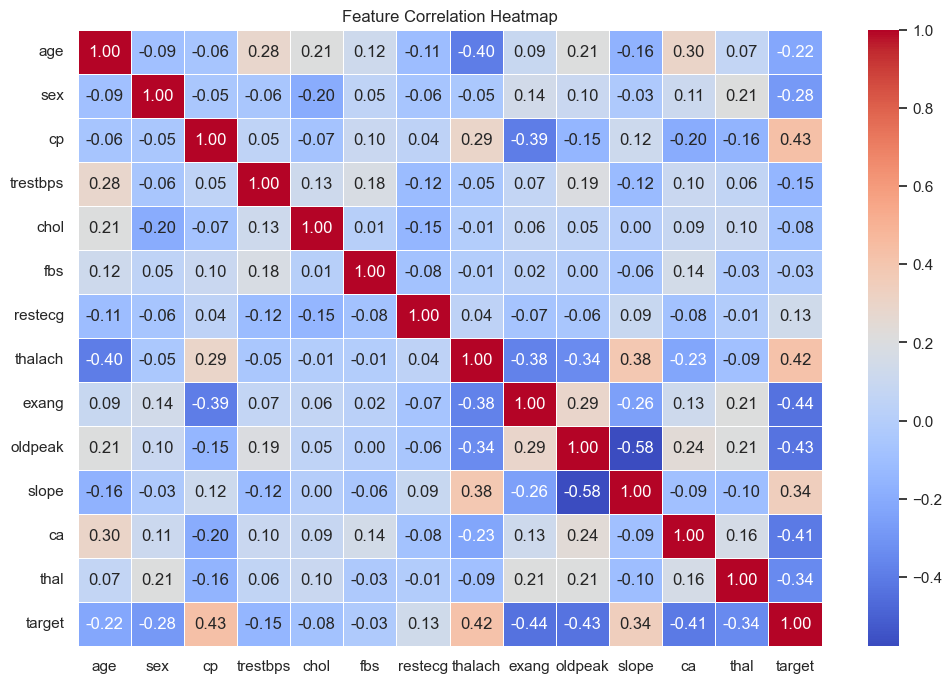

C:\Users\haris\AppData\Local\Temp\ipykernel_23944\3747984840.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='thalach', palette=['#2ecc71', '#e74c3c'])


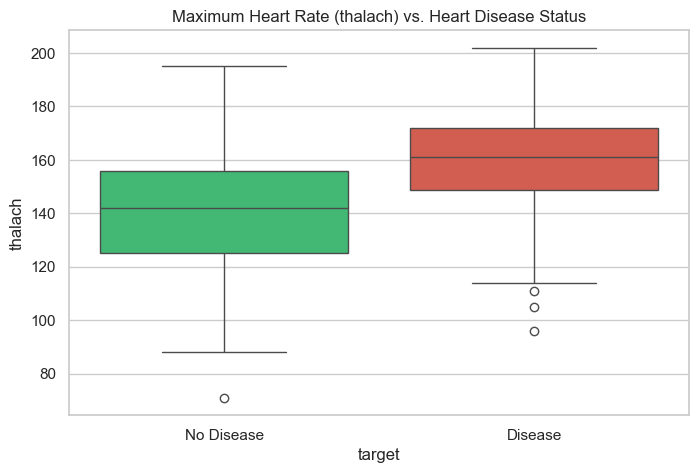

In [14]:
# Cell 5: Correlation Matrix & Feature Plots
plt.figure(figsize=(12, 8))
corr = df.corr()

# Correlation Heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Boxplot: Max Heart Rate achieved by Target
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='target', y='thalach', palette=['#2ecc71', '#e74c3c'])
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.title('Maximum Heart Rate (thalach) vs. Heart Disease Status')
plt.show()
